In [1]:
import numpy as np
import uproot
import pandas as pd
import Util
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import awkward as ak
from AlgorithmMethodDataPrep import getKeys
from Util import wrap_phi

### Get data

In [2]:
cut_var = 'logLikelihood'
cut_min = -52
cut_max = None

In [3]:
file_name = "/data/jchishol/mntuples_08_01_22/Results/KLFitter6_TestDataResults.root"

with uproot.open(file_name) as data_file:
    truth_df = data_file["parton"].arrays(library="pd")
    truth_df = truth_df.add_prefix('truth_')
    reco_df = data_file["reco"].arrays(library="pd")
    reco_df = reco_df.add_prefix('reco_')
    df = pd.concat([truth_df,reco_df], axis=1)

In [4]:
df

,truth_index,truth_th_pt,truth_th_eta,truth_th_y,truth_th_phi,truth_th_m,truth_th_E,truth_tl_pt,truth_tl_eta,truth_tl_y,...,reco_ttbar_pt,reco_ttbar_eta,reco_ttbar_y,reco_ttbar_phi,reco_ttbar_m,reco_ttbar_E,reco_ttbar_chi,reco_eventNumber,reco_jet_n,reco_logLikelihood
0,0,298396.468750,-1.655345,-1.523267,-0.387099,172109.671875,827629.937500,285370.500000,-1.074880,-0.954752,...,158.330643,-2.211951,-1.111768,2.815960,502.736603,887.787659,1.256704,9003360,5,-47.978081
1,1,58507.054688,3.011865,1.895328,-2.302530,172742.453125,620553.000000,69013.835938,-0.400520,-0.152617,...,12.230977,4.474800,0.840784,0.015735,568.796692,782.149780,3.530688,9009594,4,-61.753765
2,2,150567.484375,0.875857,0.612700,2.576738,172830.156250,273605.062500,131370.531250,1.323992,0.921984,...,36.796669,1.461580,0.136064,-0.677725,548.879089,555.211243,4.288237,9003049,4,-53.885971
3,3,100229.750000,1.175209,0.727839,0.807193,155469.578125,236175.250000,102323.234375,1.134705,0.659144,...,50.564445,2.565647,0.701481,1.204022,426.969116,540.147095,1.029909,9003913,4,-46.450035
4,4,199048.562500,0.646724,0.501429,-0.365400,173125.515625,297669.500000,164316.656250,-0.749087,-0.538978,...,26.763979,0.115620,0.005319,-1.025009,582.500183,583.122986,2.395535,9003642,4,-43.988594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3605622,3605622,36415.878906,-0.552733,-0.118418,-2.734588,174590.078125,179599.375000,70133.726562,-2.881558,-1.926522,...,65.212105,-3.061816,-1.089268,-1.790023,523.450928,872.628540,5.229882,256311264,4,-46.968525
3605623,3605623,93749.984375,-0.987200,-0.529532,-0.250278,171354.843750,223354.984375,125669.429688,-0.366254,-0.219386,...,13.500698,3.727384,0.512696,0.935850,523.589417,594.121948,6.731220,256311672,4,-44.826866
3605624,3605624,102700.328125,-2.028140,-1.405017,2.023819,171908.578125,432635.312500,225566.734375,-1.304767,-1.114259,...,139.398849,-2.886977,-1.624890,-1.641799,491.352722,1347.034668,1.388316,256311943,5,-45.022068
3605625,3605625,170457.828125,0.325820,0.231976,-0.655496,171076.562500,248028.828125,143717.703125,2.608114,2.173987,...,66.134865,3.229617,1.045054,-1.413799,666.344604,1069.791138,6.242856,256310852,5,-45.314640


### Fix Units

In [5]:
for var in list(['th_pt','tl_pt','th_m','tl_m','ttbar_pt','ttbar_m']):
    df = Util.checkUnits(df,var,'GeV')

/home/jchishol/TRecNet/TRecNet_env/lib64/python3.9/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


/home/jchishol/TRecNet/TRecNet_env/lib64/python3.9/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
truth_th_pt is estimated to be in units of MeV when units of GeV were set. Scaling to the latter units. Please ensure your histogram looks correct.
truth_tl_pt is estimated to be in units of MeV when units of GeV were set. Scaling to the latter units. Please ensure your histogram looks correct.
truth_th_m is estimated to be in units of MeV when units of GeV were set. Scaling to the latter units. Please ensure your histogram looks correct.
truth_tl_m is estimated to be in units of MeV when units of GeV were set. Scaling to the latter units. Please ensure your histogram looks correct.
truth_ttbar_pt is estimated to be in units of MeV when units of GeV were set. Scaling to the latter units. Please ensure your histogram looks correct.
truth_ttbar_m is estimated to be in units of MeV when units of GeV 

In [6]:
df[['truth_th_pt','reco_th_pt','truth_tl_pt','reco_tl_pt','truth_ttbar_pt','reco_ttbar_pt','reco_'+cut_var]]

,truth_th_pt,reco_th_pt,truth_tl_pt,reco_tl_pt,truth_ttbar_pt,reco_ttbar_pt,reco_logLikelihood
0,298.396469,115.860466,285.370500,264.739563,37.217758,158.330643,-47.978081
1,58.507055,85.225189,69.013836,94.188766,94.696008,12.230977,-61.753765
2,150.567484,92.036354,131.370531,128.419113,25.609889,36.796669,-53.885971
3,100.229750,150.909897,102.323234,102.647514,9.465035,50.564445,-46.450035
4,199.048563,212.633316,164.316656,191.625198,34.459723,26.763979,-43.988594
...,...,...,...,...,...,...,...
3605622,36.415879,110.502914,70.133727,60.101116,34.132441,65.212105,-46.968525
3605623,93.749984,34.540760,125.669430,32.937233,45.109629,13.500698,-44.826866
3605624,102.700328,110.651253,225.566734,244.536774,137.424438,139.398849,-45.022068
3605625,170.457828,172.801086,143.717703,133.658371,49.402375,66.134865,-45.314640


### Make data cuts

In [7]:
if cut_min!=None and cut_max==None:
    cut_df = df[df['reco_'+cut_var]>cut_min]
elif cut_min==None and cut_max!=None:
    cut_df = df[df['reco_'+cut_var]<cut_max]
    

In [8]:
cut_df[['truth_th_pt','reco_th_pt','truth_tl_pt','reco_tl_pt','truth_ttbar_pt','reco_ttbar_pt','reco_'+cut_var]]

,truth_th_pt,reco_th_pt,truth_tl_pt,reco_tl_pt,truth_ttbar_pt,reco_ttbar_pt,reco_logLikelihood
0,298.396469,115.860466,285.370500,264.739563,37.217758,158.330643,-47.978081
3,100.229750,150.909897,102.323234,102.647514,9.465035,50.564445,-46.450035
4,199.048563,212.633316,164.316656,191.625198,34.459723,26.763979,-43.988594
5,53.047441,63.319668,104.237570,61.370934,143.604516,112.515656,-44.178509
6,131.316766,157.794525,59.784512,98.923195,94.027523,60.172935,-43.896751
...,...,...,...,...,...,...,...
3605622,36.415879,110.502914,70.133727,60.101116,34.132441,65.212105,-46.968525
3605623,93.749984,34.540760,125.669430,32.937233,45.109629,13.500698,-44.826866
3605624,102.700328,110.651253,225.566734,244.536774,137.424438,139.398849,-45.022068
3605625,170.457828,172.801086,143.717703,133.658371,49.402375,66.134865,-45.314640


### Plots

In [10]:
plt.hist(df['truth_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='truth',color='black')
plt.hist(df['reco_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='reco')
plt.legend()
plt.close()

In [12]:
plt.hist(cut_df['truth_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='truth',color='black')
plt.hist(cut_df['reco_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='reco')
plt.legend()
plt.close()

In [13]:
color_map=colors.LinearSegmentedColormap.from_list('my_cmap', ['white', 'tab:blue'])
ticks = [0,50,80,100,130,160,190,250,300]
tick_labels = [str(t) for t in ticks]
n = len(ticks)
ran = ticks[::n-1]
H, _, _, _ = plt.hist2d(df['reco_th_pt'],df['truth_th_pt'],bins=ticks,range=[ran,ran])
#H, _, _, _ = plt.hist2d(np.clip(df['reco_th_pt'],ticks[0],ticks[-1]),np.clip(df['truth_th_pt'],ticks[0],ticks[-1]),bins=ticks,range=[ran,ran])
plt.colorbar()
print(H)

[[160861.  99318.  48406.  52414.  30836.  17574.  15812.   4894.]
 [101445. 186563.  82866.  79278.  47808.  26231.  22486.   6940.]
 [ 45089.  84453. 103295.  78802.  42617.  23282.  18957.   5545.]
 [ 42344.  68843.  81892. 192524.  86340.  43565.  34649.   8982.]
 [ 20976.  34245.  33741.  89811. 159678.  60959.  42258.   9883.]
 [  9960.  15790.  15261.  33135.  70172. 124041.  58424.  12097.]
 [  7284.  11163.  10314.  20827.  32058.  69112. 223706.  37419.]
 [  2003.   2762.   2426.   4475.   5834.   8459.  50065.  87812.]]


In [14]:
H = np.divide(H,np.sum(H,axis=0),where=np.sum(H,axis=0)!=0)
H=H*100
print(H)

[[41.25042953 19.73975279 12.79901428  9.50793265  6.4871051   4.70871302
   3.39053558  2.81957919]
 [26.01407317 37.07996033 21.91057136 14.38107919 10.05757947  7.02823781
   4.82162807  3.99834075]
 [11.56240864 16.7852891  27.31219642 14.29473249  8.96552595  6.23809358
   4.06491164  3.19463969]
 [10.8584939  13.6827544  21.65303635 34.923975   18.16372598 11.67264611
   7.42971586  5.17479778]
 [ 5.37898564  6.80629729  8.92144653 16.29177203 33.59216397 16.33313059
   9.06129853  5.69389072]
 [ 2.55409501  3.13831024  4.03515591  6.01070989 14.76239263 33.23509001
  12.52774162  6.96944208]
 [ 1.86787431  2.21868     2.72712129  3.77803093  6.74418262 18.51761547
  47.96883075 21.55820063]
 [ 0.51363979  0.54895585  0.64145785  0.81176782  1.22732427  2.2664734
  10.73533795 50.59110917]]


In [15]:
np.rint(H)

array([[41., 20., 13., 10.,  6.,  5.,  3.,  3.],
       [26., 37., 22., 14., 10.,  7.,  5.,  4.],
       [12., 17., 27., 14.,  9.,  6.,  4.,  3.],
       [11., 14., 22., 35., 18., 12.,  7.,  5.],
       [ 5.,  7.,  9., 16., 34., 16.,  9.,  6.],
       [ 3.,  3.,  4.,  6., 15., 33., 13.,  7.],
       [ 2.,  2.,  3.,  4.,  7., 19., 48., 22.],
       [ 1.,  1.,  1.,  1.,  1.,  2., 11., 51.]])

In [16]:
cm = np.rint(H).T.astype(int)
print(cm)

[[41 26 12 11  5  3  2  1]
 [20 37 17 14  7  3  2  1]
 [13 22 27 22  9  4  3  1]
 [10 14 14 35 16  6  4  1]
 [ 6 10  9 18 34 15  7  1]
 [ 5  7  6 12 16 33 19  2]
 [ 3  5  4  7  9 13 48 11]
 [ 3  4  3  5  6  7 22 51]]


In [17]:
masked_cm = np.ma.masked_where(cm==0,cm)  # Needed to make the zero bins white
plt.imshow(masked_cm,extent=[0,n-1,0,n-1],cmap=color_map,origin='lower')
plt.xticks(np.arange(n),tick_labels,fontsize=12,rotation=-25)
plt.yticks(np.arange(n),tick_labels,fontsize=12)
plt.xlabel('Reco-level th_pt', fontsize=15)
plt.ylabel('Parton-level th_pt', fontsize=15)
plt.clim(0,100)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=12)
for j in range (n-1):
    for k in range(n-1):
        if masked_cm.T[j,k] != 0:   # Don't label empty bins
            plt.text(j+0.5,k+0.5,masked_cm.T[j,k],color='k',fontsize=10,weight="bold",ha="center",va="center")

### Data

In [66]:
df.dropna(inplace=True)
print(df[['truth_th_pt','reco_th_pt']])
total_events = len(df)
print(total_events)

           truth_th_pt  reco_th_pt
0        298396.468750  115.860466
1         58507.054688   85.225189
2        150567.484375   92.036354
3        100229.750000  150.909897
4        199048.562500  212.633316
...                ...         ...
3605622    4528.484375  110.502914
3605623   62354.738281   34.540760
3605624   57486.789062  110.651253
3605625  302523.250000  172.801086
3605626  114945.851562   64.028549

[3605627 rows x 2 columns]
3605627


In [67]:
row3_df = df[df['truth_th_pt']>=80000]
row3_df = row3_df[row3_df['truth_th_pt']<100000]
row3_total = len(row3_df)
print(row3_total)
print(row3_df['reco_th_pt'])

379993
14         130.632462
21          92.946640
22         103.647163
25         110.847656
38          50.990204
              ...    
3605601    106.566986
3605602    263.047455
3605604     81.794365
3605615     87.429489
3605620    231.331284
Name: reco_th_pt, Length: 379993, dtype: float64


In [68]:
box1_df = row3_df[row3_df['reco_th_pt']>=0]
box1_df = box1_df[box1_df['reco_th_pt']<50]
box1_total = len(box1_df)
print(box1_total)
print(box1_total/row3_total)
print(box1_df['reco_th_pt'])

45888
0.12076011926535489
224        45.197262
236        30.951435
272        46.088100
401        24.299013
482        27.335178
             ...    
3605275    42.549438
3605294    47.582909
3605381    22.114298
3605452    35.781990
3605497    35.492367
Name: reco_th_pt, Length: 45888, dtype: float64


In [69]:
box3_df = row3_df[row3_df['reco_th_pt']>=80]
box3_df = box3_df[box3_df['reco_th_pt']<100]
box3_total = len(box3_df)
print(box3_total)
print(box3_total/row3_total)
print(box3_df['reco_th_pt'])

42917
0.11294155418652449
21         92.946640
138        99.069099
187        81.530640
190        84.850266
239        95.797577
             ...    
3605407    84.883743
3605416    86.790337
3605542    85.013092
3605604    81.794365
3605615    87.429489
Name: reco_th_pt, Length: 42917, dtype: float64


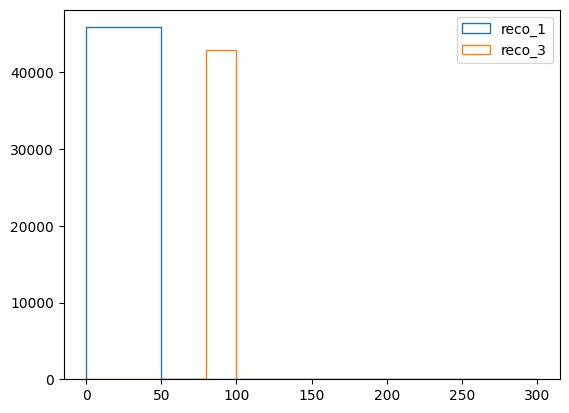

In [74]:
ticks = [0,50,80,100,130,160,190,250,300]
plt.figure('new')
plt.hist(box1_df['reco_th_pt'],histtype='step',label='reco_1',bins=ticks)
plt.hist(box3_df['reco_th_pt'],histtype='step',label='reco_3',bins=ticks)
plt.legend()

### From H5py

In [2]:
cut_var = 'logLikelihood'
cut_min = -52
cut_max = None
file_name = "/data/jchishol/mntuples_08_01_22/mc16a_6j/mntuple_ljets_3_jetMatch04.root"

In [3]:
with uproot.open(file_name) as root_file:
    keys = root_file['nominal'].keys()
truth_keys, reco_keys = getKeys('KLFitter6',keys)


In [125]:
keys

['weight_mc',
 'weight_pileup',
 'weight_leptonSF',
 'weight_bTagSF_DL1r_70',
 'weight_jvt',
 'eventNumber',
 'runNumber',
 'randomRunNumber',
 'mcChannelNumber',
 'mu',
 'mu_actual',
 'backgroundFlags',
 'hasBadMuon',
 'nel_pt',
 'el_pt',
 'nel_eta',
 'el_eta',
 'nel_cl_eta',
 'el_cl_eta',
 'nel_phi',
 'el_phi',
 'nel_e',
 'el_e',
 'nel_charge',
 'el_charge',
 'nel_topoetcone20',
 'el_topoetcone20',
 'nel_ptvarcone20',
 'el_ptvarcone20',
 'nel_CF',
 'el_CF',
 'nel_d0sig',
 'el_d0sig',
 'nel_delta_z0_sintheta',
 'el_delta_z0_sintheta',
 'nel_true_type',
 'el_true_type',
 'nel_true_origin',
 'el_true_origin',
 'nel_true_firstEgMotherTruthType',
 'el_true_firstEgMotherTruthType',
 'nel_true_firstEgMotherTruthOrigin',
 'el_true_firstEgMotherTruthOrigin',
 'nel_true_firstEgMotherPdgId',
 'el_true_firstEgMotherPdgId',
 'nel_true_IFFclass',
 'el_true_IFFclass',
 'nel_true_isPrompt',
 'el_true_isPrompt',
 'nel_true_isChargeFl',
 'el_true_isChargeFl',
 'nmu_pt',
 'mu_pt',
 'nmu_eta',
 'mu_eta'

In [5]:
print(truth_keys)
print(reco_keys)

[['th_pt', 'MC_thad_afterFSR_pt'], ['th_eta', 'MC_thad_afterFSR_eta'], ['th_y', 'MC_thad_afterFSR_y'], ['th_phi', 'MC_thad_afterFSR_phi'], ['th_m', 'MC_thad_afterFSR_m'], ['th_E', 'MC_thad_afterFSR_E'], ['tl_pt', 'MC_tlep_afterFSR_pt'], ['tl_eta', 'MC_tlep_afterFSR_eta'], ['tl_y', 'MC_tlep_afterFSR_y'], ['tl_phi', 'MC_tlep_afterFSR_phi'], ['tl_m', 'MC_tlep_afterFSR_m'], ['tl_E', 'MC_tlep_afterFSR_E'], ['ttbar_pt', 'MC_ttbar_afterFSR_pt'], ['ttbar_eta', 'MC_ttbar_afterFSR_eta'], ['ttbar_y', 'MC_ttbar_afterFSR_y'], ['ttbar_phi', 'MC_ttbar_afterFSR_phi'], ['ttbar_m', 'MC_ttbar_afterFSR_m'], ['ttbar_E', 'MC_ttbar_afterFSR_E'], ['ttbar_yboost', 'MC_y_boost'], ['ttbar_chi', 'MC_chi_tt']]
[['th_pt', 'klfitter_bestPerm_topHad_pt'], ['th_eta', 'klfitter_bestPerm_topHad_eta'], ['th_y', 'klfitter_bestPerm_topHad_y'], ['th_phi', 'klfitter_bestPerm_topHad_phi'], ['th_m', 'klfitter_bestPerm_topHad_m'], ['th_E', 'klfitter_bestPerm_topHad_E'], ['tl_pt', 'klfitter_bestPerm_topLep_pt'], ['tl_eta', 'klfi

In [87]:
with uproot.open(file_name) as root_file:
    tree_nom = root_file['nominal'].arrays()

df_nom_truth = ak.to_dataframe({new_name:tree_nom[old_name] for (new_name,old_name) in truth_keys})
df_nom_reco = ak.to_dataframe({new_name:tree_nom[old_name] for (new_name,old_name) in reco_keys})

df_nom_truth['eventNumber'] = tree_nom['eventNumber']
df_nom_reco['eventNumber'] = tree_nom['eventNumber']

df_truth = df_nom_truth.copy()
df_reco = df_nom_reco.copy()

In [94]:
print(len(df_truth['eventNumber']))
print(len(df_reco['eventNumber']))

25541
25541


In [91]:
df_truth.loc[df_truth['eventNumber'] != df_reco['eventNumber'] ]

,th_pt,th_eta,th_y,th_phi,th_m,th_E,tl_pt,tl_eta,tl_y,tl_phi,...,tl_E,ttbar_pt,ttbar_eta,ttbar_y,ttbar_phi,ttbar_m,ttbar_E,ttbar_yboost,ttbar_chi,eventNumber
entry,,,,,,,,,,,,,,,,,,,,,


In [95]:
df_reco['logLikelihood'] = ak.flatten(ak.fill_none(ak.pad_none(tree_nom['klfitter_logLikelihood'],1),np.nan))

In [96]:
for df in [df_reco]:
    df.replace([np.inf,-np.inf],np.nan,inplace=True)
    df.dropna(inplace=True)

In [101]:
df_reco.loc[df_reco['logLikelihood'].isna()]

,th_pt,th_eta,th_y,th_phi,th_m,th_E,tl_pt,tl_eta,tl_y,tl_phi,...,tl_E,ttbar_pt,ttbar_eta,ttbar_y,ttbar_phi,ttbar_m,ttbar_E,ttbar_chi,eventNumber,logLikelihood
entry,,,,,,,,,,,,,,,,,,,,,


In [105]:
common_idx = df_truth.index.intersection(df_reco.index)

In [107]:
df_truth = df_truth.loc[common_idx]
df_reco = df_reco.loc[common_idx]

In [109]:
df_reco

,th_pt,th_eta,th_y,th_phi,th_m,th_E,tl_pt,tl_eta,tl_y,tl_phi,...,tl_E,ttbar_pt,ttbar_eta,ttbar_y,ttbar_phi,ttbar_m,ttbar_E,ttbar_chi,eventNumber,logLikelihood
entry,,,,,,,,,,,,,,,,,,,,,
0,20.816031,-2.535751,-0.694448,-2.555063,172.486633,217.342438,76.407219,-1.977771,-1.158390,0.557734,...,330.032349,55.603043,-2.674588,-0.935800,0.546955,367.993866,547.374817,1.590330,394386580,-46.175476
1,61.154770,2.033910,1.050798,1.282903,172.513504,293.729431,59.927784,-1.198743,-0.476353,-2.035768,...,203.741531,10.776126,3.254711,0.287936,2.651500,477.416565,497.470978,4.605040,394385780,-52.222088
2,221.257019,-0.697002,-0.564770,0.647481,172.507309,326.505432,179.266403,-0.102073,-0.073612,-2.433028,...,249.459976,43.716869,-2.151233,-0.333643,0.394461,543.575195,575.965393,1.634207,394386329,-44.992142
3,244.514252,-1.023885,-0.874780,-2.386837,172.488831,421.213776,260.764038,-0.248646,-0.208018,0.638849,...,319.445648,33.461742,-3.076398,-0.534344,-0.367851,645.325012,740.659424,1.947920,394385152,-44.494122
4,94.598022,0.337182,0.164477,-1.656211,172.499054,199.402252,205.261627,0.389830,0.301467,-2.953779,...,280.396606,248.113480,0.446732,0.243474,-2.577862,394.362488,479.798859,1.146816,394386249,-44.326176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25536,81.328201,-2.282721,-1.473939,2.998069,172.486176,438.169250,87.710487,-1.415007,-0.792280,-0.054975,...,257.507446,9.830014,-4.743497,-1.130695,0.765765,406.636169,695.676697,1.977156,394666072,-44.117416
25537,93.571915,-0.981619,-0.522797,3.082297,172.492279,223.671829,84.261864,-1.611476,-0.920216,-0.555765,...,279.167419,44.614845,-2.636809,-0.719356,-2.082012,393.386932,502.839233,1.487978,394666981,-50.553364
25538,69.942245,-2.405681,-1.472708,0.094124,172.497223,427.216522,152.995880,-0.471380,-0.319048,-2.762930,...,242.413696,88.082024,-2.353769,-0.840327,-2.538138,479.207428,669.630249,3.169774,394666073,-43.633049


## Plotting this now

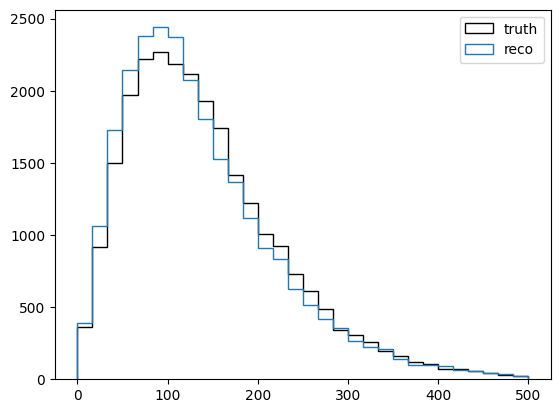

In [119]:
matplotlib.pyplot.ion()
plt.hist(df_truth['th_pt']/1000,range=(0,500),bins=30,histtype='step',label='truth',color='black')
plt.hist(df_reco['th_pt'],range=(0,500),bins=30,histtype='step',label='reco')
plt.legend()
plt.show()
plt.close()

[[1187.  739.  358.  371.  232.  132.   99.   64.]
 [ 700. 1397.  620.  564.  326.  176.  162.  100.]
 [ 335.  648.  737.  552.  295.  160.  115.   76.]
 [ 283.  504.  584. 1294.  651.  303.  292.  125.]
 [ 138.  242.  217.  627. 1155.  407.  282.  110.]
 [  67.  112.  107.  237.  472.  873.  397.  118.]
 [  47.   64.   61.  165.  211.  489. 1598.  394.]
 [  21.   32.   36.   52.   67.   85.  440. 2034.]]


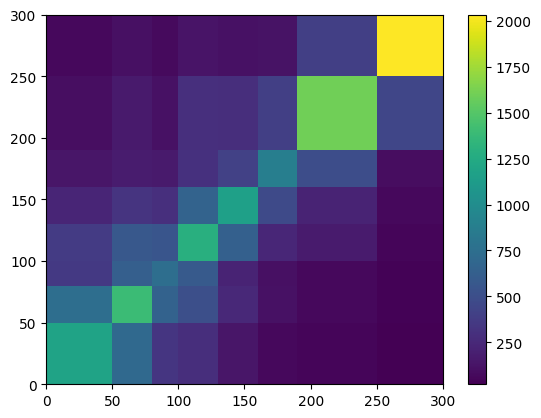

In [152]:
color_map=colors.LinearSegmentedColormap.from_list('my_cmap', ['white', 'tab:blue'])
ticks = [0,50,80,100,130,160,190,250,300]
tick_labels = [str(t) for t in ticks]
n = len(ticks)
ran = ticks[::n-1]
H, _, _, _ = plt.hist2d(np.clip(df_reco['th_pt'],ticks[0],ticks[-1]),np.clip(df_truth['th_pt']/1000,ticks[0],ticks[-1]),bins=ticks,range=[ran,ran])
#H, _, _, _ = plt.hist2d(np.clip(df['reco_th_pt'],ticks[0],ticks[-1]),np.clip(df['truth_th_pt'],ticks[0],ticks[-1]),bins=ticks,range=[ran,ran])
plt.colorbar()
print(H)

In [153]:
H = np.divide(H,np.sum(H,axis=0),where=np.sum(H,axis=0)!=0)
H=H*100
print(H)

[[42.72858171 19.76993044 13.16176471  9.60642154  6.80551481  5.02857143
   2.92466765  2.11850381]
 [25.19798416 37.3729267  22.79411765 14.60383221  9.56292168  6.7047619
   4.78581979  3.3101622 ]
 [12.05903528 17.33547352 27.09558824 14.29311238  8.6535641   6.0952381
   3.39734121  2.51572327]
 [10.18718503 13.48314607 21.47058824 33.50595546 19.09650924 11.54285714
   8.62629247  4.13770275]
 [ 4.96760259  6.47405029  7.97794118 16.23511134 33.88090349 15.5047619
   8.33087149  3.64117842]
 [ 2.41180706  2.99625468  3.93382353  6.13671673 13.84570255 33.25714286
  11.7282127   3.90599139]
 [ 1.69186465  1.71214553  2.24264706  4.27239772  6.18949839 18.62857143
  47.20827179 13.04203906]
 [ 0.75593952  0.85607277  1.32352941  1.34645262  1.96538574  3.23809524
  12.9985229  67.32869911]]


In [154]:
cm = np.rint(H).T.astype(int)
print(cm)

[[43 25 12 10  5  2  2  1]
 [20 37 17 13  6  3  2  1]
 [13 23 27 21  8  4  2  1]
 [10 15 14 34 16  6  4  1]
 [ 7 10  9 19 34 14  6  2]
 [ 5  7  6 12 16 33 19  3]
 [ 3  5  3  9  8 12 47 13]
 [ 2  3  3  4  4  4 13 67]]


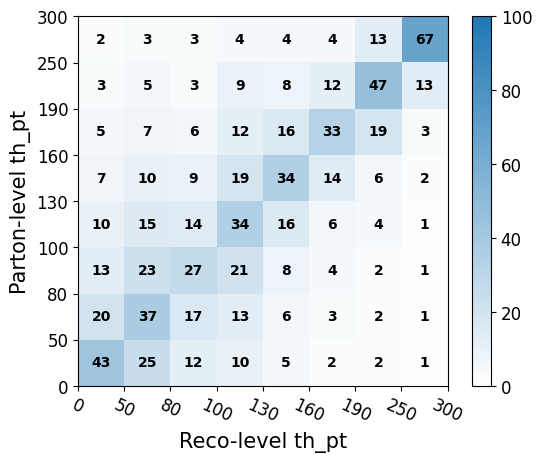

In [155]:
masked_cm = np.ma.masked_where(cm==0,cm)  # Needed to make the zero bins white
plt.imshow(masked_cm,extent=[0,n-1,0,n-1],cmap=color_map,origin='lower')
plt.xticks(np.arange(n),tick_labels,fontsize=12,rotation=-25)
plt.yticks(np.arange(n),tick_labels,fontsize=12)
plt.xlabel('Reco-level th_pt', fontsize=15)
plt.ylabel('Parton-level th_pt', fontsize=15)
plt.clim(0,100)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=12)
for j in range (n-1):
    for k in range(n-1):
        if masked_cm.T[j,k] != 0:   # Don't label empty bins
            plt.text(j+0.5,k+0.5,masked_cm.T[j,k],color='k',fontsize=10,weight="bold",ha="center",va="center")

In [193]:
ticks = [0,50,80,100,130,160,190,250,1000]
from itertools import combinations
res = max(combinations(ticks[:-1], 2), key = lambda sub: abs(sub[0]-sub[1]))
res = np.ptp(ticks[:-1])
print(res)
ticks[-1] = res*1.75


hey = r'$\infty$'
print(hey == r'$\infty$')

250
True


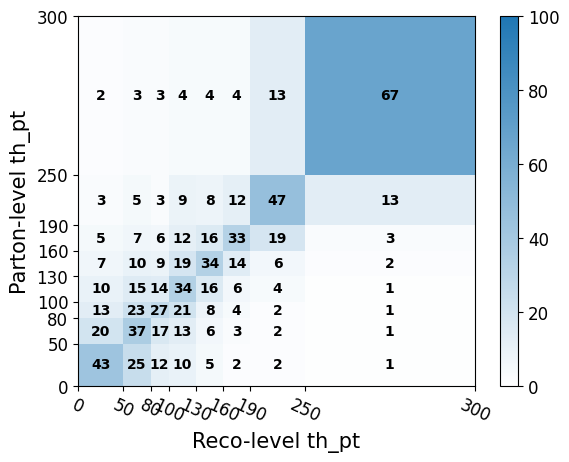

In [194]:
masked_cm = np.ma.masked_where(cm==0,cm)  # Needed to make the zero bins white
plt.pcolormesh(ticks,ticks,masked_cm,cmap=color_map)
plt.xticks(ticks,tick_labels,fontsize=12,rotation=-25)
plt.yticks(ticks,tick_labels,fontsize=12)
plt.xlabel('Reco-level th_pt', fontsize=15)
plt.ylabel('Parton-level th_pt', fontsize=15)
plt.clim(0,100)
plt.clim(0,100)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=12)
for j in range (n-1):
    for k in range(n-1):
        if masked_cm.T[j,k] != 0:   # Don't label empty bins
            plt.text((ticks[j]+ticks[j+1])/2,(ticks[k]+ticks[k+1])/2,masked_cm.T[j,k],color='k',fontsize=10,weight="bold",ha="center",va="center")

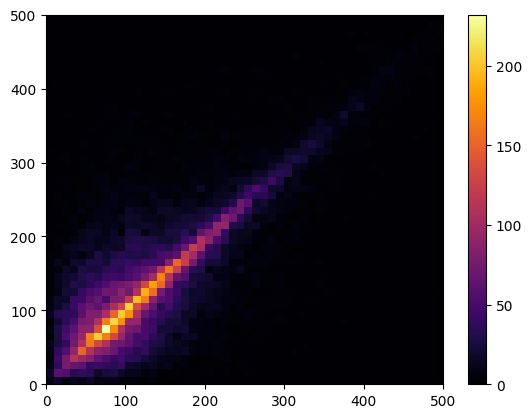

In [159]:
plt.hist2d(df_reco['th_pt'],df_truth['th_pt']/1000,bins=50,range=[[0,500],[0,500]],cmap='inferno')
plt.colorbar()